# Interactive noise playground

Weeeee I love noisy play!

In [3]:
from matplotlib import pyplot as plt
import numpy as np
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.append("src/forest_gen")

from heightmap.terrain import normalized_noise2

RANGE = 100000
expected_value = np.mean([normalized_noise2(float(np.random.random() * RANGE), float(np.random.random() * RANGE)) for _ in range(RANGE)])
print("Expected value:", expected_value)

Expected value: 0.5001377255739238


In [ ]:
from heightmap import NOISE_FUNC

print(repr(NOISE_FUNC))
print(tuple(NOISE_FUNC(float(i), float(i)) for i in range(100)))

MultiLayerFunc(func=normalized_noise2)
(np.float64(2.5), np.float64(2.1852112032078983), np.float64(1.9028708778373762), np.float64(1.7651328518259262), np.float64(1.7036858259763368), np.float64(1.5097575580814624), np.float64(1.4156443489604689), np.float64(1.664337278993465), np.float64(1.9206379099949977), np.float64(1.8073423355293152), np.float64(1.3991803628580861), np.float64(1.0614949814532002), np.float64(0.8719195769685903), np.float64(0.9676470395379286), np.float64(1.3262863601951715), np.float64(1.7665157686946715), np.float64(2.0224806570527325), np.float64(2.1278991174538686), np.float64(2.265721513585051), np.float64(2.411579401070476), np.float64(2.376893641367744), np.float64(2.0914761974763723), np.float64(1.7982769899153146), np.float64(1.6654660309326275), np.float64(1.6131466220783062), np.float64(1.5645532161985085), np.float64(1.5747007385993017), np.float64(1.5502504482221617), np.float64(1.4870901875221842), np.float64(1.44421314290854), np.float64(1.46973682

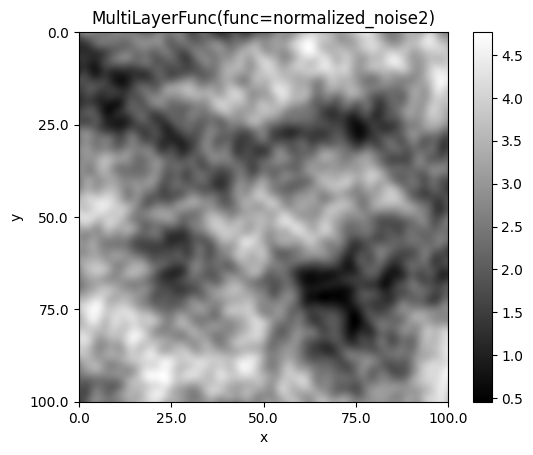

In [ ]:
def noise_range(size=10, step=0.1) -> np.ndarray:
    # return the range of the NOISE_FUNC in a 2D grid
    noise = []
    for y in np.arange(0, size, step=step):
        row = []
        for x in np.arange(0, size, step=step):
            row.append(NOISE_FUNC(float(x), float(y)))
        noise.append(row)
    return np.array(noise)

def plot_noise_func(size=10, step=0.1):
    noise = noise_range(size=size, step=step)
    plt.imshow(noise, cmap='gray')
    plt.title(repr(NOISE_FUNC))
    plt.xlabel('x')
    plt.ylabel('y')
    plt.xticks(ticks=np.linspace(0, noise.shape[1], 5), labels=[str(label) for label in np.round(np.linspace(0, size, 5), 2)])
    plt.yticks(ticks=np.linspace(0, noise.shape[0], 5), labels=[str(label) for label in np.round(np.linspace(0, size, 5), 2)])
    plt.colorbar()

plot_noise_func(size=100)
    

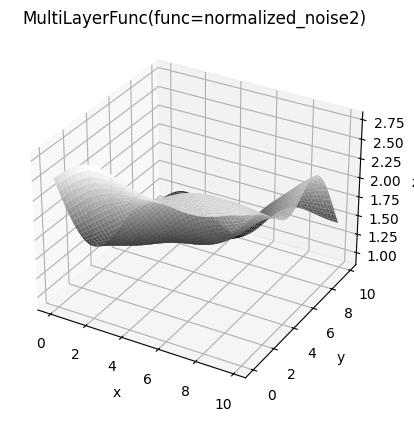

In [31]:

def plot_noise_func_3d(size=10, step=0.1):
    noise = noise_range(size=size, step=step)
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    x = np.arange(0, size, step=step)
    y = np.arange(0, size, step=step)
    x, y = np.meshgrid(x, y)
    ax.plot_surface(x, y, noise, cmap='gray')
    ax.set_title(repr(NOISE_FUNC))
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    plt.show()
plot_noise_func_3d(size=10)


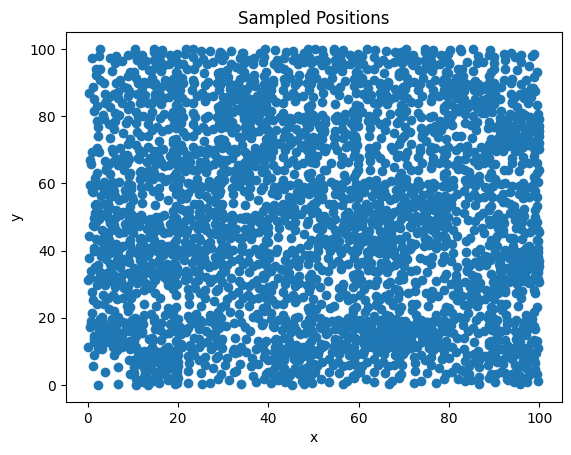

In [17]:
from forest_gen.asset_dist import sample_positions

positions = sample_positions(100, 100, 3.0, 10.0)

def plot_positions(positions: list[tuple[float, float]]):
    fig, ax = plt.subplots()
    positions_array = np.array(positions)  # Convert list of arrays to a single 2D numpy array
    ax.scatter(positions_array[:, 0], positions_array[:, 1])
    ax.set_title("Sampled Positions")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.show()
    
plot_positions(positions)
